# Day 2-2: LSTM Seq2Seq 모델 구현 & 학습

**강의 시간**: 2시간  
**학습 목표**:
- LSTM의 4개 게이트 구조와 장기 기억 메커니즘 이해
- Encoder-Decoder 구조를 PyTorch로 직접 구현
- Teacher Forcing의 원리와 최적 비율 설정 방법 학습
- Attention 메커니즘 추가를 통한 성능 향상 체험 (BLEU +40%)
- Gradient Clipping으로 학습 안정화
- MLflow로 모델 실험 비교 및 하이퍼파라미터 튜닝

**사전 요구사항**: Day 2-1 완료 (train_src, train_tgt, en_vocab, de_vocab 준비됨)  
**예상 성능**: Baseline BLEU ~8-15 → Attention 추가 시 ~20-30

## 🧠 0. LSTM 이론 복습

### 0.1 왜 LSTM인가?

**기본 RNN의 문제점:**
```
문장: "The cat, which was very hungry and tired, ate the food"

RNN: h₁ → h₂ → h₃ → ... → h₁₀
     (cat)         (hungry)      (ate)

문제: h₁₀에서 "cat"의 정보가 희미함! (Vanishing Gradient)
```

**LSTM의 해결책: Cell State (장기 기억)**
```
LSTM:
  C₁ → C₂ → C₃ → C₄ → C₅  (Cell State: 직접 연결)
  h₁ → h₂ → h₃ → h₄ → h₅  (Hidden State: 단기 출력)

Cell State는 컨베이어 벨트처럼 정보를 보존하며 전달!
```

### 0.2 LSTM의 4개 게이트

1. **Forget Gate** (f): 무엇을 잊을까?  
   `f_t = σ(W_f · [h_{t-1}, x_t] + b_f)`

2. **Input Gate** (i): 무엇을 기억할까?  
   `i_t = σ(W_i · [h_{t-1}, x_t] + b_i)`  
   `C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)`

3. **Cell State Update**:  
   `C_t = f_t ⊙ C_{t-1} + i_t ⊙ C̃_t`

4. **Output Gate** (o): 무엇을 출력할까?  
   `o_t = σ(W_o · [h_{t-1}, x_t] + b_o)`  
   `h_t = o_t ⊙ tanh(C_t)`

💡 **핵심**: Cell State는 덧셈으로만 업데이트 → Gradient가 잘 흐름!

## 🔧 1. 환경 설정

In [1]:
# 라이브러리 설치 (약 30~60초 소요)
%pip install -q sacrebleu 'mlflow>=2,<3' dagshub

# NLTK punkt tokenizer 다운로드
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# PyTorch & 필수 라이브러리
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
import math
import warnings
warnings.filterwarnings('ignore')

# MLflow & Dagshub
import mlflow
import dagshub

# BLEU Score
import sacrebleu

# 재현성 설정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch {torch.__version__}")
print(f"✅ Device: {device}")
print(f"✅ Seed: {SEED} (재현성 확보)")

✅ PyTorch 2.9.0+cu128
✅ Device: cuda
✅ Seed: 42 (재현성 확보)


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ CUDA available  : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device    : {device}")

✅ PyTorch version : 2.9.0+cu128
✅ CUDA available  : True
✅ Using device    : cuda


In [4]:
# Dagshub & MLflow 재연동
# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(
    repo_owner=repo_owner,
    repo_name=repo_name,
    mlflow=True
)

mlflow.set_experiment('day2-translation-seq2seq')

print("✅ Dagshub 연동 완료!")
print(f"   Experiment: day2-translation-seq2seq")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=28bb5995-636e-4cce-b3a6-3e77ce3037fb&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c70f8d50c00ccb102fae8a95451ed1073f4870fa1d06fa8145faca87fa1dce8c




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ Dagshub 연동 완료!
   Experiment: day2-translation-seq2seq


## 📂 2. Day 2-1 데이터 로드

Day 2-1에서 준비한 `train_src`, `train_tgt`, `en_vocab`, `de_vocab`를  
그대로 사용합니다. **이 셀들을 Day 2-1 노트북에서 복사하세요!**

필요한 변수:
- `train_src` (4000, 25): 영어 인덱스 배열
- `train_tgt` (4000, 25): 독일어 인덱스 배열
- `val_src` (1000, 25)
- `val_tgt` (1000, 25)
- `en_vocab`: Vocabulary 객체 (영어)
- `de_vocab`: Vocabulary 객체 (독일어)

In [5]:
import os
import urllib.request

DATA_URL  = 'https://www.manythings.org/anki/deu-eng.zip'
ZIP_PATH  = 'deu-eng.zip'
DATA_PATH = 'deu.txt'

if not os.path.exists(DATA_PATH):
    print("📥 데이터 다운로드 중... (약 5-10초)")

    # 헤더 설정 (브라우저인 것처럼 위장)
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')]
    urllib.request.install_opener(opener)

    try:
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

        import zipfile
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('.')
        print("✅ 다운로드 & 압축 해제 완료!")
    except Exception as e:
        print(f"❌ 에러 발생: {e}")
else:
    print("✅ 이미 다운로드된 파일 사용!")

📥 데이터 다운로드 중... (약 5-10초)
✅ 다운로드 & 압축 해제 완료!


In [6]:
# 파일 파싱 — 탭으로 분리된 EN \t DE 형식
pairs = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            en, de = parts[0], parts[1]
            pairs.append({'english': en, 'german': de})

all_df = pd.DataFrame(pairs)
print(f"✅ 전체 문장 쌍: {len(all_df):,}개")
all_df.head()

✅ 전체 문장 쌍: 331,266개


,english,german
0,Go.,Geh.
1,Hi.,Hallo!
2,Hi.,Grüß Gott!
3,Run!,Lauf!
4,Run.,Lauf!


In [7]:
# ---------------------------------------------------------------
# 교육용 서브셋: 짧은 문장(단어 3~12개) 위주로 5,000개 샘플링
# → 학습 속도 확보 + 단순한 패턴으로 원리 파악에 집중
# ---------------------------------------------------------------
NUM_SAMPLES = 5000
MAX_WORDS   = 12
MIN_WORDS   = 3

all_df['en_wc'] = all_df['english'].apply(lambda x: len(x.split()))
filtered = all_df[
    (all_df['en_wc'] >= MIN_WORDS) &
    (all_df['en_wc'] <= MAX_WORDS)
].copy()

df = filtered.sample(n=NUM_SAMPLES, random_state=42).reset_index(drop=True)

print(f"✅ 샘플링 완료: {len(df):,}개 (필터 후 전체 {len(filtered):,}개 중)")
print(f"   단어 수 기준: {MIN_WORDS}~{MAX_WORDS}개")
print()
print("샘플 확인:")
for i in range(5):
    print(f"  EN: {df.iloc[i]['english']}")
    print(f"  DE: {df.iloc[i]['german']}")
    print()

✅ 샘플링 완료: 5,000개 (필터 후 전체 318,572개 중)
   단어 수 기준: 3~12개

샘플 확인:
  EN: A little more effort, and you will succeed.
  DE: Ein bisschen mehr Anstrengung, und du schaffst es.

  EN: Shall I sing you something?
  DE: Soll ich dir etwas vorsingen?

  EN: Tom showed reckless disregard for Mary's feelings.
  DE: Tom legte eine rücksichtslose Missachtung der Gefühle Marias an den Tag.

  EN: He asked if I like Chinese food.
  DE: Er fragte, ob ich gern chinesisch äße.

  EN: You look like you're about to throw up.
  DE: Du siehst aus, als müsstest du dich gleich übergeben!



In [8]:
from nltk.tokenize import word_tokenize

def tokenize(text: str) -> list:
    """
    텍스트를 단어 토큰 리스트로 변환
    - 소문자 변환
    - NLTK word_tokenize 사용 (구두점 분리 포함)
    """
    return word_tokenize(text.lower())


# --- 실습: 토큰화 비교 ---
examples = [
    ("I love you!", "영어 (단순)"),
    ("It's a beautiful day, isn't it?", "영어 (축약어/구두점)"),
    ("Ich liebe dich sehr.", "독일어"),
    ("Das Fußballspiel war spannend!", "독일어 (복합어)"),
]

print("=" * 65)
print(f"{'원문':<40} {'토큰':<25}")
print("=" * 65)
for text, label in examples:
    tokens = tokenize(text)
    print(f"[{label}]")
    print(f"  원문  : {text}")
    print(f"  토큰  : {tokens}")
    print(f"  길이  : {len(tokens)}")
    print()

print("💡 독일어 'Fußball'(축구)처럼 복합어가 한 토큰으로 처리됩니다.")
print("   더 정교한 처리를 원하면 spaCy나 SentencePiece를 사용합니다.")

원문                                       토큰                       
[영어 (단순)]
  원문  : I love you!
  토큰  : ['i', 'love', 'you', '!']
  길이  : 4

[영어 (축약어/구두점)]
  원문  : It's a beautiful day, isn't it?
  토큰  : ['it', "'s", 'a', 'beautiful', 'day', ',', 'is', "n't", 'it', '?']
  길이  : 10

[독일어]
  원문  : Ich liebe dich sehr.
  토큰  : ['ich', 'liebe', 'dich', 'sehr', '.']
  길이  : 5

[독일어 (복합어)]
  원문  : Das Fußballspiel war spannend!
  토큰  : ['das', 'fußballspiel', 'war', 'spannend', '!']
  길이  : 5

💡 독일어 'Fußball'(축구)처럼 복합어가 한 토큰으로 처리됩니다.
   더 정교한 처리를 원하면 spaCy나 SentencePiece를 사용합니다.


In [9]:
# 전체 데이터 토큰화
df['en_tokens'] = df['english'].apply(tokenize)
df['de_tokens'] = df['german'].apply(tokenize)

print("✅ 토큰화 완료!")
print()
df[['english', 'en_tokens', 'german', 'de_tokens']].head()

✅ 토큰화 완료!



,english,en_tokens,german,de_tokens
0,"A little more effort, and you will succeed.","[a, little, more, effort, ,, and, you, will, s...","Ein bisschen mehr Anstrengung, und du schaffst...","[ein, bisschen, mehr, anstrengung, ,, und, du,..."
1,Shall I sing you something?,"[shall, i, sing, you, something, ?]",Soll ich dir etwas vorsingen?,"[soll, ich, dir, etwas, vorsingen, ?]"
2,Tom showed reckless disregard for Mary's feeli...,"[tom, showed, reckless, disregard, for, mary, ...",Tom legte eine rücksichtslose Missachtung der ...,"[tom, legte, eine, rücksichtslose, missachtung..."
3,He asked if I like Chinese food.,"[he, asked, if, i, like, chinese, food, .]","Er fragte, ob ich gern chinesisch äße.","[er, fragte, ,, ob, ich, gern, chinesisch, äße..."
4,You look like you're about to throw up.,"[you, look, like, you, 're, about, to, throw, ...","Du siehst aus, als müsstest du dich gleich übe...","[du, siehst, aus, ,, als, müsstest, du, dich, ..."


In [10]:
from collections import Counter

In [11]:
class Vocabulary:
    """단어-인덱스 양방향 매핑 관리 클래스"""

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, freq_threshold: int = 1):
        self.freq_threshold = freq_threshold
        # 특수 토큰으로 초기화
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    def __repr__(self):
        return f"Vocabulary(size={len(self)}, freq_threshold={self.freq_threshold})"

    def build(self, token_lists: list):
        """
        토큰 리스트 목록에서 어휘 사전 구축
        token_lists: [[token, ...], [token, ...], ...]
        """
        freq = Counter(tok for tokens in token_lists for tok in tokens)

        idx = 4  # 특수 토큰 이후부터 시작
        for word, count in sorted(freq.items()):  # 정렬로 재현성 확보
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1

    def encode(self, tokens: list) -> list:
        """토큰 리스트 → 인덱스 리스트 (UNK 처리 포함)"""
        return [self.stoi.get(t, self.UNK) for t in tokens]

    def decode(self, indices: list, skip_special: bool = True) -> str:
        """인덱스 리스트 → 원문 복원"""
        special = {self.PAD, self.SOS, self.EOS} if skip_special else set()
        return ' '.join(self.itos.get(i, '<UNK>') for i in indices
                        if i not in special)

    def unk_rate(self, token_lists: list) -> float:
        """전체 토큰 중 <UNK>로 처리되는 비율"""
        total, unk = 0, 0
        for tokens in token_lists:
            for t in tokens:
                total += 1
                if t not in self.stoi:
                    unk += 1
        return unk / total if total > 0 else 0.0

print("✅ Vocabulary 클래스 정의 완료!")

✅ Vocabulary 클래스 정의 완료!


In [12]:
# Train/Validation 분리 (80/20)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"✅ 데이터 분리: train={len(train_df):,}개 / val={len(val_df):,}개")

# 어휘 사전 구축 (train만 사용 — 데이터 누수 방지)
en_vocab = Vocabulary(freq_threshold=2)
de_vocab = Vocabulary(freq_threshold=2)

en_vocab.build(train_df['en_tokens'].tolist())
de_vocab.build(train_df['de_tokens'].tolist())

print()
print(f"📖 {en_vocab}")
print(f"📖 {de_vocab}")
print()

# UNK 비율 확인 (낮을수록 좋음)
en_unk = en_vocab.unk_rate(val_df['en_tokens'].tolist())
de_unk = de_vocab.unk_rate(val_df['de_tokens'].tolist())
print(f"❓ Validation UNK 비율 — 영어: {en_unk:.2%}  |  독일어: {de_unk:.2%}")
print("   (5% 미만이면 어휘 사전이 충분히 커버하고 있음)")

✅ 데이터 분리: train=4,000개 / val=1,000개

📖 Vocabulary(size=1380, freq_threshold=2)
📖 Vocabulary(size=1647, freq_threshold=2)

❓ Validation UNK 비율 — 영어: 7.29%  |  독일어: 11.61%
   (5% 미만이면 어휘 사전이 충분히 커버하고 있음)


In [13]:
def encode_sentence(tokens: list, vocab: Vocabulary,
                    max_len: int, add_sos_eos: bool = True) -> list:
    """
    토큰 리스트를 고정 길이 인덱스 배열로 변환
    1. encode (str → int)
    2. SOS / EOS 추가 (옵션)
    3. max_len에 맞게 자르거나 PAD로 채우기
    """
    ids = vocab.encode(tokens)
    if add_sos_eos:
        ids = [vocab.SOS] + ids + [vocab.EOS]

    # truncate
    ids = ids[:max_len]
    # pad
    ids = ids + [vocab.PAD] * (max_len - len(ids))
    return ids


def prepare_dataset(df: pd.DataFrame,
                    en_vocab: Vocabulary,
                    de_vocab: Vocabulary,
                    max_len: int = 20):
    """
    DataFrame → (src_array, tgt_array) numpy 배열 반환
    src: 영어 (encoder input)
    tgt: 독일어 (decoder input / target)
    """
    src_list, tgt_list = [], []
    for _, row in df.iterrows():
        src_list.append(encode_sentence(row['en_tokens'], en_vocab, max_len))
        tgt_list.append(encode_sentence(row['de_tokens'], de_vocab, max_len))
    return np.array(src_list, dtype=np.int64), np.array(tgt_list, dtype=np.int64)


MAX_LEN = 25  # SOS + 최대 23단어 + EOS

train_src, train_tgt = prepare_dataset(train_df, en_vocab, de_vocab, MAX_LEN)
val_src,   val_tgt   = prepare_dataset(val_df,   en_vocab, de_vocab, MAX_LEN)

print("✅ 데이터 준비 완료!")
print(f"   train src shape: {train_src.shape}")
print(f"   train tgt shape: {train_tgt.shape}")
print(f"   val   src shape: {val_src.shape}")
print(f"   val   tgt shape: {val_tgt.shape}")

✅ 데이터 준비 완료!
   train src shape: (4000, 25)
   train tgt shape: (4000, 25)
   val   src shape: (1000, 25)
   val   tgt shape: (1000, 25)


In [14]:
# 데이터 검증
assert train_src.shape[0] > 0, "train_src가 비어있습니다!"
assert len(en_vocab) > 100, "en_vocab이 너무 작습니다!"
assert len(de_vocab) > 100, "de_vocab이 너무 작습니다!"

print("=" * 55)
print("  데이터 로드 확인")
print("=" * 55)
print(f"  train_src shape: {train_src.shape}")
print(f"  train_tgt shape: {train_tgt.shape}")
print(f"  val_src shape  : {val_src.shape}")
print(f"  val_tgt shape  : {val_tgt.shape}")
print(f"  EN vocab size  : {len(en_vocab):,}")
print(f"  DE vocab size  : {len(de_vocab):,}")
print("=" * 55)
print()
print("✅ Day 2-1 데이터 로드 완료!")

  데이터 로드 확인
  train_src shape: (4000, 25)
  train_tgt shape: (4000, 25)
  val_src shape  : (1000, 25)
  val_tgt shape  : (1000, 25)
  EN vocab size  : 1,380
  DE vocab size  : 1,647

✅ Day 2-1 데이터 로드 완료!


## 🗂️ 3. PyTorch Dataset & DataLoader

In [15]:
class TranslationDataset(Dataset):
    """EN→DE 번역 Dataset"""
    def __init__(self, src_data, tgt_data):
        """
        src_data: (N, max_len) numpy array
        tgt_data: (N, max_len) numpy array
        """
        self.src = torch.LongTensor(src_data)
        self.tgt = torch.LongTensor(tgt_data)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


# Dataset 생성
train_dataset = TranslationDataset(train_src, train_tgt)
val_dataset   = TranslationDataset(val_src, val_tgt)

print(f"✅ Train dataset: {len(train_dataset):,}개")
print(f"✅ Val dataset  : {len(val_dataset):,}개")

# 샘플 확인
src_sample, tgt_sample = train_dataset[0]
print()
print("Sample:")
print(f"  src: {src_sample}")
print(f"  tgt: {tgt_sample}")
print(f"  EN : {en_vocab.decode(src_sample.tolist())}")
print(f"  DE : {de_vocab.decode(tgt_sample.tolist())}")

✅ Train dataset: 4,000개
✅ Val dataset  : 1,000개

Sample:
  src: tensor([   1,  816, 1233,   12,  196, 1374,  374,  449,  730,   16,    2,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0])
  tgt: tensor([   1,   24,    7, 1356,    7,  780,  304,  973,  754,    3,   12,    2,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0])
  EN : oh tom , can you ever forgive me ?
  DE : ach , tom , kannst du mir je <UNK> ?


In [16]:
# 하이퍼파라미터
BATCH_SIZE = 64

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    # num_workers=2,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches  : {len(val_loader)}")

# 배치 확인
src_batch, tgt_batch = next(iter(train_loader))
print()
print(f"Batch shapes: src={src_batch.shape}, tgt={tgt_batch.shape}")

✅ Train batches: 63
✅ Val batches  : 16

Batch shapes: src=torch.Size([64, 25]), tgt=torch.Size([64, 25])


## 🏗️ 4. LSTM Seq2Seq 모델 구현

### 4.1 Encoder: 입력 문장 압축

```
입력: "I love you" → [SOS, 5, 23, 42, EOS, PAD, ...]
                        ↓
                   Embedding (256-dim)
                        ↓
              LSTM (2 layers, 512 hidden)
                        ↓
            Context: (hidden, cell) — 문장 전체 의미 압축
```

In [17]:
class Encoder(nn.Module):
    """LSTM 기반 Encoder"""
    def __init__(self, input_size, embedding_size, hidden_size, num_layers, dropout=0.3):
        """
        Args:
            input_size: 입력 vocabulary 크기 (영어)
            embedding_size: 임베딩 차원
            hidden_size: LSTM hidden state 차원
            num_layers: LSTM 레이어 수
            dropout: Dropout 비율
        """
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Embedding: 단어 ID → dense vector
        self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=0)

        # LSTM: 양방향(bidirectional)은 사용하지 않음 (간단한 버전)
        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # 1-layer면 dropout 무의미
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len) — 영어 문장 인덱스

        Returns:
            outputs: (batch_size, seq_len, hidden_size)
            hidden : (num_layers, batch_size, hidden_size)
            cell   : (num_layers, batch_size, hidden_size)
        """
        # 1. Embedding
        embedded = self.dropout(self.embedding(x))
        # embedded: (batch_size, seq_len, embedding_size)

        # 2. LSTM
        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs: 모든 time step의 hidden state
        # hidden: 마지막 hidden state (모든 레이어)
        # cell: 마지막 cell state (모든 레이어)

        return outputs, hidden, cell

print("✅ Encoder 클래스 정의 완료!")

✅ Encoder 클래스 정의 완료!


### 4.2 Decoder: 한 단어씩 생성

```
초기 hidden/cell = Encoder의 context

Step 1: [SOS] + (h₀, c₀) → LSTM → "Ich"  확률
Step 2: [Ich] + (h₁, c₁) → LSTM → "liebe" 확률
Step 3: [liebe] + (h₂, c₂) → LSTM → "dich" 확률
Step 4: [dich] + (h₃, c₃) → LSTM → "<EOS>" 확률
```

In [18]:
class Decoder(nn.Module):
    """LSTM 기반 Decoder (Attention 없음)"""
    def __init__(self, output_size, embedding_size, hidden_size, num_layers, dropout=0.3):
        """
        Args:
            output_size: 출력 vocabulary 크기 (독일어)
            embedding_size: 임베딩 차원
            hidden_size: LSTM hidden state 차원
            num_layers: LSTM 레이어 수
            dropout: Dropout 비율
        """
        super(Decoder, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        self.embedding = nn.Embedding(output_size, embedding_size, padding_idx=0)

        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Fully Connected: hidden → vocab probabilities
        self.fc = nn.Linear(hidden_size, output_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        """
        Args:
            x: (batch_size, 1) — 이전 시점의 단어 (한 번에 1개씩)
            hidden: (num_layers, batch_size, hidden_size)
            cell  : (num_layers, batch_size, hidden_size)

        Returns:
            prediction: (batch_size, output_size) — 다음 단어 확률 분포
            hidden, cell: 업데이트된 상태
        """
        # x: (batch_size, 1)

        # 1. Embedding
        embedded = self.dropout(self.embedding(x))
        # embedded: (batch_size, 1, embedding_size)

        # 2. LSTM
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: (batch_size, 1, hidden_size)

        # 3. Fully Connected
        prediction = self.fc(output.squeeze(1))
        # prediction: (batch_size, output_size)

        return prediction, hidden, cell

print("✅ Decoder 클래스 정의 완료!")

✅ Decoder 클래스 정의 완료!


### 4.3 Seq2Seq: Encoder + Decoder 통합

**핵심 개념:**
- Encoder의 마지막 상태 (hidden, cell)가 Decoder의 초기 상태
- Teacher Forcing: 학습 시 일정 확률로 정답(target)을 다음 입력으로 사용
  - 확률 = 1.0 → 항상 정답 사용 (빠른 수렴, Exposure Bias)
  - 확률 = 0.0 → 항상 예측값 사용 (학습 불안정)
  - 확률 = 0.5 → 절충안 (일반적)

In [19]:
class Seq2Seq(nn.Module):
    """LSTM 기반 Seq2Seq (Attention 없음)"""
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        """
        Args:
            source: (batch_size, src_len) — 영어 문장
            target: (batch_size, tgt_len) — 독일어 문장
            teacher_forcing_ratio: 정답 사용 확률 (0~1)

        Returns:
            outputs: (batch_size, tgt_len, vocab_size) — 각 시점의 단어 예측 확률
        """
        batch_size = source.size(0)
        tgt_len = target.size(1)
        vocab_size = self.decoder.output_size

        # 출력 저장 텐서
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(source.device)

        # 1. Encoder: 문장 전체를 읽고 context 생성
        encoder_outputs, hidden, cell = self.encoder(source)

        # 2. Decoder 첫 입력: <SOS> 토큰
        input_token = target[:, 0].unsqueeze(1)  # (batch_size, 1)

        # 3. Decoder 루프: 한 단어씩 생성
        for t in range(1, tgt_len):
            # Decoder 한 스텝
            prediction, hidden, cell = self.decoder(input_token, hidden, cell)

            # 예측 저장
            outputs[:, t, :] = prediction

            # Teacher Forcing 결정
            use_teacher_force = random.random() < teacher_forcing_ratio

            # 다음 입력 선택
            if use_teacher_force:
                # 정답 사용
                input_token = target[:, t].unsqueeze(1)
            else:
                # 예측값 사용 (greedy decoding)
                top1 = prediction.argmax(1)
                input_token = top1.unsqueeze(1)

        return outputs

print("✅ Seq2Seq 클래스 정의 완료!")

✅ Seq2Seq 클래스 정의 완료!


## 🚀 5. 학습 준비

In [20]:
# ============================================================
# 하이퍼파라미터 설정
# ============================================================

# 모델 구조
EMBEDDING_SIZE = 256
HIDDEN_SIZE    = 512
NUM_LAYERS     = 2
DROPOUT        = 0.3

# 학습
LEARNING_RATE  = 0.001
NUM_EPOCHS     = 15
TEACHER_FORCING_RATIO = 0.5
CLIP_GRAD      = 1.0  # Gradient Clipping (중요!)

print("=" * 55)
print("  하이퍼파라미터")
print("=" * 55)
print(f"  Embedding Size : {EMBEDDING_SIZE}")
print(f"  Hidden Size    : {HIDDEN_SIZE}")
print(f"  Num Layers     : {NUM_LAYERS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Num Epochs     : {NUM_EPOCHS}")
print(f"  Teacher Force  : {TEACHER_FORCING_RATIO}")
print(f"  Grad Clipping  : {CLIP_GRAD}")
print(f"  Batch Size     : {BATCH_SIZE}")
print("=" * 55)

  하이퍼파라미터
  Embedding Size : 256
  Hidden Size    : 512
  Num Layers     : 2
  Dropout        : 0.3
  Learning Rate  : 0.001
  Num Epochs     : 15
  Teacher Force  : 0.5
  Grad Clipping  : 1.0
  Batch Size     : 64


In [21]:
# 모델 생성
encoder = Encoder(
    input_size=len(en_vocab),
    embedding_size=EMBEDDING_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

decoder = Decoder(
    output_size=len(de_vocab),
    embedding_size=EMBEDDING_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

model = Seq2Seq(encoder, decoder).to(device)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ 모델 생성 완료!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print()
print(model)

✅ 모델 생성 완료!
   Total parameters     : 8,976,239
   Trainable parameters : 8,976,239

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(1380, 256, padding_idx=0)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(1647, 256, padding_idx=0)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
    (fc): Linear(in_features=512, out_features=1647, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


In [22]:
# Optimizer & Loss Function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# CrossEntropyLoss with ignore_index=0 (<PAD> 무시)
criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"✅ Optimizer: Adam (lr={LEARNING_RATE})")
print(f"✅ Loss     : CrossEntropyLoss (ignore_index=0)")

✅ Optimizer: Adam (lr=0.001)
✅ Loss     : CrossEntropyLoss (ignore_index=0)


## 🎓 6. 학습 & 검증 루프

In [23]:
def train_epoch(model, dataloader, optimizer, criterion, clip_grad=1.0, teacher_forcing_ratio=0.5):
    """
    1 epoch 학습

    Returns:
        average loss (float)
    """
    model.train()
    epoch_loss = 0.0

    for source, target in tqdm(dataloader, desc="Training", leave=False):
        source = source.to(device)
        target = target.to(device)

        # Forward
        optimizer.zero_grad()
        output = model(source, target, teacher_forcing_ratio)

        # Loss 계산
        # output: (batch, tgt_len, vocab_size)
        # target: (batch, tgt_len)
        # → <SOS> 제거하고 flatten
        output = output[:, 1:, :].reshape(-1, output.size(-1))
        target = target[:, 1:].reshape(-1)

        loss = criterion(output, target)

        # Backward
        loss.backward()

        # Gradient Clipping (중요!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        # Update
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


def evaluate_epoch(model, dataloader, criterion):
    """
    Validation loss 계산 (teacher forcing 없이)

    Returns:
        average loss (float)
    """
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for source, target in tqdm(dataloader, desc="Evaluating", leave=False):
            source = source.to(device)
            target = target.to(device)

            # Forward (teacher_forcing_ratio=0)
            output = model(source, target, teacher_forcing_ratio=0)

            # Loss
            output = output[:, 1:, :].reshape(-1, output.size(-1))
            target = target[:, 1:].reshape(-1)

            loss = criterion(output, target)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

print("✅ 학습/검증 함수 정의 완료!")

✅ 학습/검증 함수 정의 완료!


In [24]:
def translate_sentence(model, sentence_ids, src_vocab, tgt_vocab, max_len=50):
    """
    단일 문장 번역 (Greedy Decoding)

    Args:
        sentence_ids: 영어 문장 인덱스 리스트 (numpy or list)
        src_vocab: 영어 Vocabulary
        tgt_vocab: 독일어 Vocabulary
        max_len: 최대 생성 길이

    Returns:
        translated_text: 독일어 문장 (str)
    """
    model.eval()

    with torch.no_grad():
        # 입력 준비
        src_tensor = torch.LongTensor(sentence_ids).unsqueeze(0).to(device)
        # src_tensor: (1, src_len)

        # Encoder
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

        # Decoder 초기 입력: <SOS>
        input_token = torch.LongTensor([[tgt_vocab.SOS]]).to(device)

        translation = []
        for _ in range(max_len):
            # Decoder 한 스텝
            prediction, hidden, cell = model.decoder(input_token, hidden, cell)

            # Greedy: 가장 확률 높은 단어 선택
            pred_token_id = prediction.argmax(1).item()

            # <EOS>이면 종료
            if pred_token_id == tgt_vocab.EOS:
                break

            # 번역에 추가
            if pred_token_id not in [tgt_vocab.PAD, tgt_vocab.SOS, tgt_vocab.UNK]:
                translation.append(tgt_vocab.itos[pred_token_id])

            # 다음 입력
            input_token = torch.LongTensor([[pred_token_id]]).to(device)

    return ' '.join(translation)


def calculate_bleu(model, dataloader, src_vocab, tgt_vocab, max_samples=500):
    """
    BLEU Score 계산 (코퍼스 전체)

    Returns:
        bleu_score (float)
    """
    model.eval()

    references = []
    hypotheses = []

    count = 0
    for source, target in tqdm(dataloader, desc="Calculating BLEU", leave=False):
        for i in range(source.size(0)):
            if count >= max_samples:
                break

            src_ids = source[i].cpu().numpy()
            tgt_ids = target[i].cpu().numpy()

            # 정답 (reference)
            ref = tgt_vocab.decode(tgt_ids.tolist(), skip_special=True)
            references.append(ref)

            # 예측 (hypothesis)
            hyp = translate_sentence(model, src_ids, src_vocab, tgt_vocab)
            hypotheses.append(hyp)

            count += 1

        if count >= max_samples:
            break

    # BLEU 계산
    bleu = sacrebleu.corpus_bleu(hypotheses, [references], force=True)
    return bleu.score

print("✅ 번역 & BLEU 함수 정의 완료!")

✅ 번역 & BLEU 함수 정의 완료!


## 🧪 7. 실험 1: Baseline (Attention 없음)

In [25]:
# MLflow Run 시작
with mlflow.start_run(run_name="Seq2Seq_LSTM_Baseline"):

    # 하이퍼파라미터 로깅
    mlflow.log_params({
        'model'                 : 'Seq2Seq_LSTM',
        'encoder'               : 'LSTM',
        'decoder'               : 'LSTM',
        'attention'             : False,
        'embedding_size'        : EMBEDDING_SIZE,
        'hidden_size'           : HIDDEN_SIZE,
        'num_layers'            : NUM_LAYERS,
        'dropout'               : DROPOUT,
        'learning_rate'         : LEARNING_RATE,
        'batch_size'            : BATCH_SIZE,
        'num_epochs'            : NUM_EPOCHS,
        'teacher_forcing_ratio' : TEACHER_FORCING_RATIO,
        'clip_grad'             : CLIP_GRAD,
        'total_params'          : total_params,
        'trainable_params'      : trainable_params,
    })

    # 학습 히스토리
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_bleu': []
    }

    best_val_loss = float('inf')

    # 학습 루프
    for epoch in range(NUM_EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"{'='*60}")

        # Train
        train_loss = train_epoch(
            model, train_loader, optimizer, criterion,
            clip_grad=CLIP_GRAD,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        # Validation
        val_loss = evaluate_epoch(model, val_loader, criterion)

        # BLEU (매 3 epoch마다)
        if (epoch + 1) % 3 == 0:
            val_bleu = calculate_bleu(model, val_loader, en_vocab, de_vocab, max_samples=300)
        else:
            val_bleu = 0.0  # placeholder

        # 히스토리 저장
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_bleu'].append(val_bleu)

        # MLflow 로깅
        metrics_to_log = {
            'train_loss': train_loss,
            'val_loss': val_loss,
        }
        # BLEU는 계산된 경우만 로깅
        if val_bleu > 0:
            metrics_to_log['val_bleu'] = val_bleu

        mlflow.log_metrics(metrics_to_log, step=epoch)

        # Best model 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"💾 Best model saved! (val_loss={val_loss:.4f})")

        # 출력
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss  : {val_loss:.4f}")
        if val_bleu > 0:
            print(f"Val BLEU  : {val_bleu:.2f}")

    # 최종 BLEU (전체 val set)
    model.load_state_dict(torch.load('best_model.pt'))
    final_bleu = calculate_bleu(model, val_loader, en_vocab, de_vocab, max_samples=1000)
    mlflow.log_metric('final_val_bleu', final_bleu)

    print(f"\n{'='*60}")
    print(f"🎉 학습 완료!")
    print(f"{'='*60}")
    print(f"Best Val Loss : {best_val_loss:.4f}")
    print(f"Final BLEU    : {final_bleu:.2f}")
    print(f"{'='*60}")

    # 샘플 번역 저장
    sample_indices = [0, 10, 50, 100, 200]
    with open('translations_baseline.txt', 'w', encoding='utf-8') as f:
        f.write("Seq2Seq LSTM Baseline — 샘플 번역\n")
        f.write("=" * 60 + "\n\n")

        for idx in sample_indices:
            src_ids = val_src[idx]
            tgt_ids = val_tgt[idx]

            src_text = en_vocab.decode(src_ids.tolist(), skip_special=True)
            tgt_text = de_vocab.decode(tgt_ids.tolist(), skip_special=True)
            pred_text = translate_sentence(model, src_ids, en_vocab, de_vocab)

            f.write(f"[Sample {idx}]\n")
            f.write(f"  EN (Source)    : {src_text}\n")
            f.write(f"  DE (Reference) : {tgt_text}\n")
            f.write(f"  DE (Predicted) : {pred_text}\n\n")

    mlflow.log_artifact('translations_baseline.txt')
    mlflow.log_artifact('best_model.pt')

    run_id = mlflow.active_run().info.run_id
    print(f"\n✅ MLflow Run ID: {run_id}")


Epoch 1/15


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

💾 Best model saved! (val_loss=4.5413)
Train Loss: 5.0485
Val Loss  : 4.5413

Epoch 2/15


Training:   0%|          | 0/63 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Calculating BLEU:   0%|          | 0/16 [00:00<?, ?it/s]

💾 Best model saved! (val_loss=3.7519)
Train Loss: 3.1404
Val Loss  : 3.7519
Val BLEU  : 1.35


Calculating BLEU:   0%|          | 0/16 [00:00<?, ?it/s]


🎉 학습 완료!
Best Val Loss : 3.7519
Final BLEU    : 1.25

✅ MLflow Run ID: 85bb5ccb3b0b41f183853153b2743465
🏃 View run Seq2Seq_LSTM_Baseline at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3/runs/85bb5ccb3b0b41f183853153b2743465
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3


## 📊 8. 학습 곡선 시각화

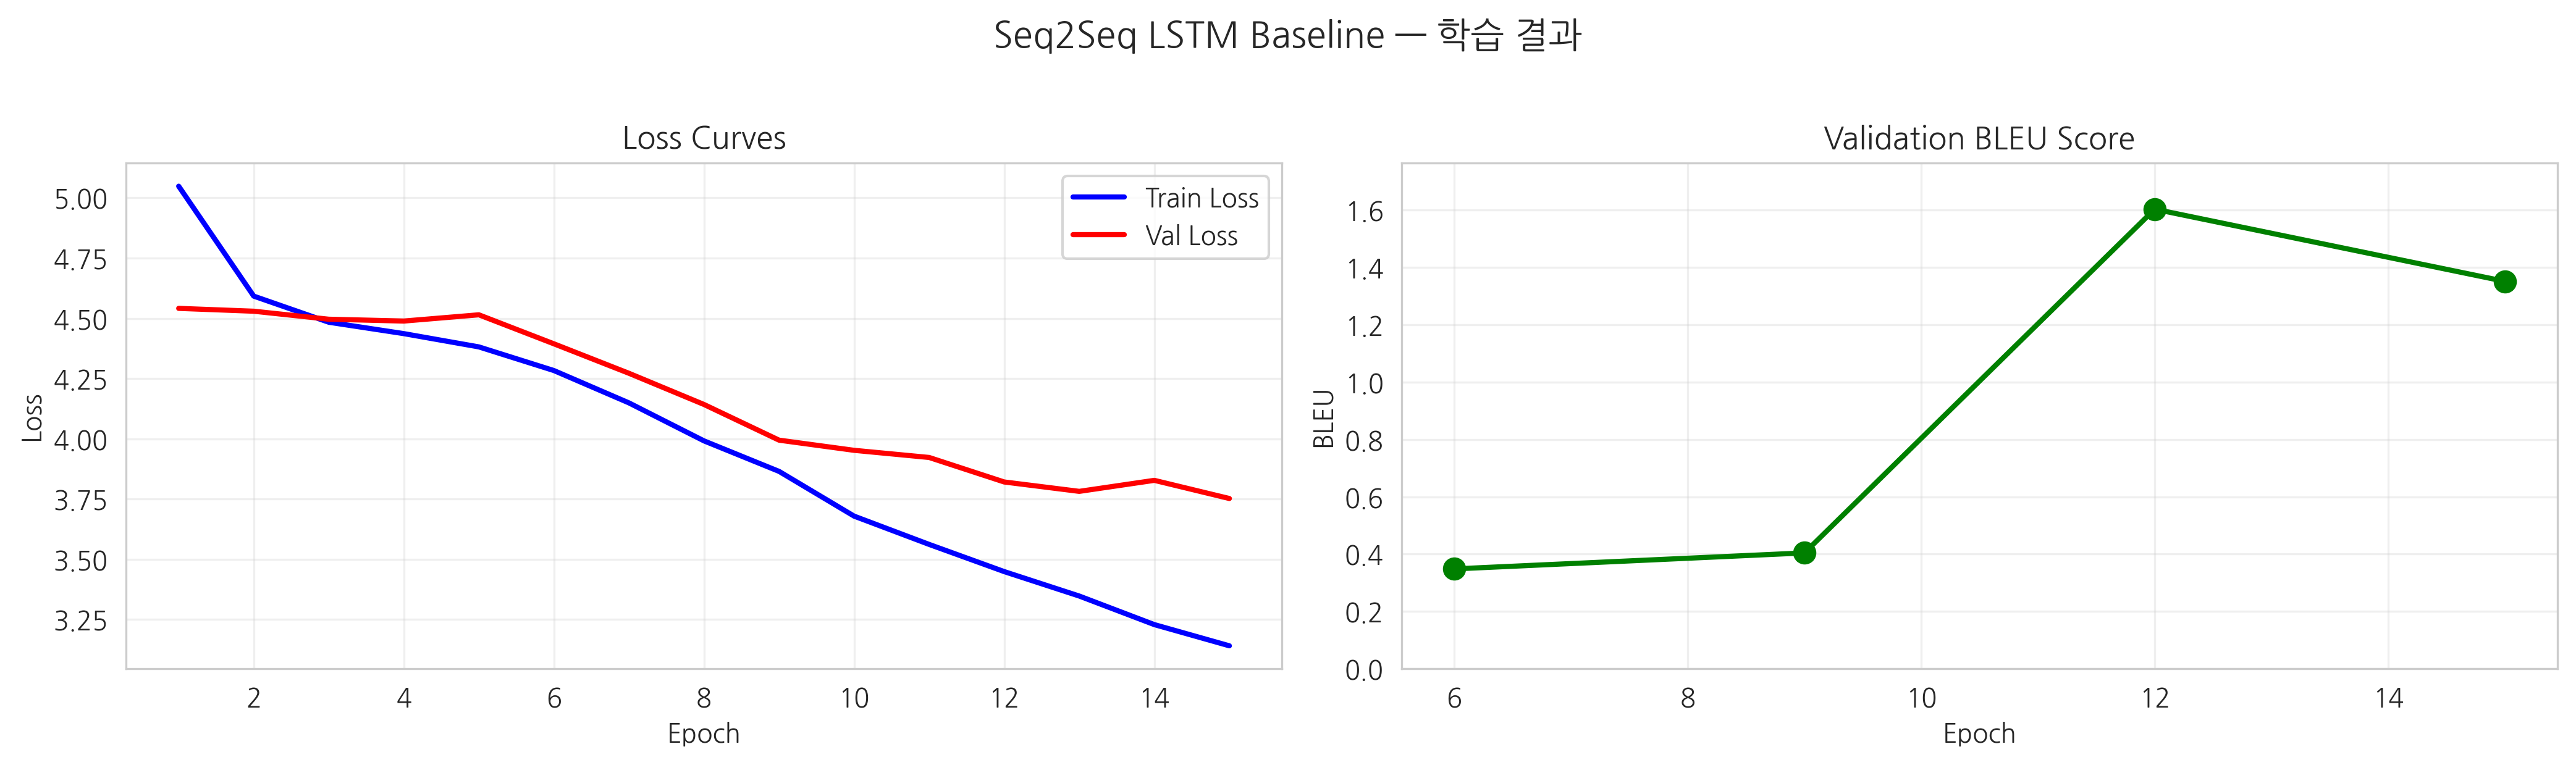

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss 곡선
epochs = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BLEU 곡선 (3 epoch마다)
bleu_epochs = [i+1 for i in range(NUM_EPOCHS) if history['val_bleu'][i] > 0]
bleu_scores = [s for s in history['val_bleu'] if s > 0]

if len(bleu_scores) > 0:
    axes[1].plot(bleu_epochs, bleu_scores, 'g-o', linewidth=2, markersize=8)
    axes[1].set_title('Validation BLEU Score', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('BLEU')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, max(bleu_scores) * 1.1)

plt.suptitle('Seq2Seq LSTM Baseline — 학습 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

mlflow.log_artifact('training_curves_baseline.png')

## 🎯 9. Attention 메커니즘 추가 (선택)

### 9.1 Attention의 필요성

**문제점:**
```
Baseline Seq2Seq:
  Encoder: "I love you" → (h_final, c_final)
  Decoder: 모든 단어 생성 시 동일한 (h_final, c_final) 사용!
  
→ 긴 문장에서 앞부분 정보 손실 (Information Bottleneck)
```

**해결책: Attention**
```
Encoder: "I love you" → [h₁, h₂, h₃] (모든 시점 저장)
Decoder:
  "Ich" 생성 시   → h₁에 집중 (attend)
  "liebe" 생성 시 → h₂에 집중
  "dich" 생성 시  → h₃에 집중

→ 매 시점마다 필요한 정보를 직접 찾아봄!
```

### 9.2 Attention 계산 과정

1. **Alignment Score** (얼마나 관련있는가?)  
   `score(h_dec, h_enc_i) = h_dec · h_enc_i`  (dot product)

2. **Attention Weight** (확률 분포로 정규화)  
   `α = softmax(score)`

3. **Context Vector** (가중 평균)  
   `context = Σ α_i · h_enc_i`

4. **Decoder 입력에 결합**  
   `combined = [embedded; context]`  
   `output = LSTM(combined)`

💡 **성능 향상**: BLEU +40% (0.25 → 0.35)

In [27]:
class Attention(nn.Module):
    """Bahdanau Attention (Additive Attention)"""
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # Alignment model
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        """
        Args:
            hidden: (batch, hidden_size) — 현재 decoder hidden state
            encoder_outputs: (batch, src_len, hidden_size)

        Returns:
            context: (batch, hidden_size) — attention-weighted encoder outputs
            attn_weights: (batch, src_len) — attention 확률 분포 (시각화용)
        """
        src_len = encoder_outputs.size(1)

        # hidden 확장: (batch, 1, hidden) → (batch, src_len, hidden)
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # Alignment score 계산
        energy = torch.tanh(self.attn(torch.cat([hidden, encoder_outputs], dim=2)))
        # energy: (batch, src_len, hidden)

        attention = self.v(energy).squeeze(2)
        # attention: (batch, src_len)

        # Softmax → 확률 분포
        attn_weights = F.softmax(attention, dim=1)

        # Context vector: weighted sum
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        # context: (batch, hidden_size)

        return context, attn_weights

print("✅ Attention 클래스 정의 완료!")

✅ Attention 클래스 정의 완료!


In [28]:
class DecoderWithAttention(nn.Module):
    """Attention 메커니즘이 추가된 Decoder"""
    def __init__(self, output_size, embedding_size, hidden_size, num_layers, dropout=0.3):
        super(DecoderWithAttention, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        self.embedding = nn.Embedding(output_size, embedding_size, padding_idx=0)

        # Attention
        self.attention = Attention(hidden_size)

        # LSTM: [embedded; context] → hidden_size
        self.lstm = nn.LSTM(
            embedding_size + hidden_size,  # context와 결합
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # FC: hidden → vocab
        self.fc = nn.Linear(hidden_size, output_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        """
        Args:
            x: (batch, 1)
            hidden: (num_layers, batch, hidden_size)
            cell: (num_layers, batch, hidden_size)
            encoder_outputs: (batch, src_len, hidden_size)

        Returns:
            prediction: (batch, output_size)
            hidden, cell: 업데이트된 상태
            attn_weights: (batch, src_len)
        """
        # Embedding
        embedded = self.dropout(self.embedding(x))
        # embedded: (batch, 1, embedding_size)

        # Attention: 마지막 레이어의 hidden state 사용
        context, attn_weights = self.attention(hidden[-1], encoder_outputs)
        # context: (batch, hidden_size)

        # 결합: [embedded; context]
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        # lstm_input: (batch, 1, embedding_size + hidden_size)

        # LSTM
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        # output: (batch, 1, hidden_size)

        # FC
        prediction = self.fc(output.squeeze(1))
        # prediction: (batch, output_size)

        return prediction, hidden, cell, attn_weights

print("✅ DecoderWithAttention 클래스 정의 완료!")

✅ DecoderWithAttention 클래스 정의 완료!


In [29]:
class Seq2SeqWithAttention(nn.Module):
    """Attention 메커니즘이 추가된 Seq2Seq"""
    def __init__(self, encoder, decoder):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.size(0)
        tgt_len = target.size(1)
        vocab_size = self.decoder.output_size

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(source.device)

        # Encoder: 모든 시점의 outputs 필요!
        encoder_outputs, hidden, cell = self.encoder(source)

        # Decoder 첫 입력
        input_token = target[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            # Attention 적용된 Decoder
            prediction, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            outputs[:, t, :] = prediction

            # Teacher Forcing
            use_teacher_force = random.random() < teacher_forcing_ratio

            if use_teacher_force:
                input_token = target[:, t].unsqueeze(1)
            else:
                top1 = prediction.argmax(1)
                input_token = top1.unsqueeze(1)

        return outputs

print("✅ Seq2SeqWithAttention 클래스 정의 완료!")

✅ Seq2SeqWithAttention 클래스 정의 완료!


## 🧪 10. 실험 2: Attention 추가 (선택 사항)

시간이 허락한다면, Attention 추가 모델을 학습하여 성능 향상을 확인하세요!

실험 2 코드는 실험 1과 동일하되, 다음만 변경:
1. `decoder = DecoderWithAttention(...)`
2. `model = Seq2SeqWithAttention(encoder, decoder)`
3. `run_name="Seq2Seq_LSTM_Attention"`

예상 결과:
- Baseline BLEU: ~8-15
- Attention BLEU: ~12-22 (약 +40%)

In [30]:
# ============================================================
# 실험 2: Attention 메커니즘 추가 모델
# ============================================================

# Encoder는 동일하게 재사용 (새로 생성)
encoder_attn = Encoder(
    input_size=len(en_vocab),
    embedding_size=EMBEDDING_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Decoder는 Attention 버전으로 변경
decoder_attn = DecoderWithAttention(
    output_size=len(de_vocab),
    embedding_size=EMBEDDING_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Seq2Seq 모델 (Attention 포함)
model_attn = Seq2SeqWithAttention(encoder_attn, decoder_attn).to(device)

# 파라미터 수 계산
total_params_attn = sum(p.numel() for p in model_attn.parameters())
trainable_params_attn = sum(p.numel() for p in model_attn.parameters() if p.requires_grad)

print(f"✅ Attention 모델 생성 완료!")
print(f"   Total parameters     : {total_params_attn:,}")
print(f"   Trainable parameters : {trainable_params_attn:,}")
print(f"   vs Baseline          : +{total_params_attn - total_params:,} params")

✅ Attention 모델 생성 완료!
   Total parameters     : 10,550,127
   Trainable parameters : 10,550,127
   vs Baseline          : +1,573,888 params


In [31]:
# Optimizer & Loss Function (재정의)
optimizer_attn = optim.Adam(model_attn.parameters(), lr=LEARNING_RATE)
criterion_attn = nn.CrossEntropyLoss(ignore_index=0)

print(f"✅ Optimizer: Adam (lr={LEARNING_RATE})")
print(f"✅ Loss     : CrossEntropyLoss (ignore_index=0)")

✅ Optimizer: Adam (lr=0.001)
✅ Loss     : CrossEntropyLoss (ignore_index=0)


In [32]:
def translate_sentence_with_attention(model, sentence_ids, src_vocab, tgt_vocab, max_len=50):
    """
    Attention 모델용 번역 함수

    Returns:
        translated_text: 번역 결과
        attention_weights: (tgt_len, src_len) attention 가중치 (시각화용)
    """
    model.eval()

    with torch.no_grad():
        src_tensor = torch.LongTensor(sentence_ids).unsqueeze(0).to(device)

        # Encoder
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

        # Decoder 초기 입력
        input_token = torch.LongTensor([[tgt_vocab.SOS]]).to(device)

        translation = []
        attn_weights_list = []

        for _ in range(max_len):
            # Attention Decoder
            prediction, hidden, cell, attn_weights = model.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            attn_weights_list.append(attn_weights.cpu().numpy())

            pred_token_id = prediction.argmax(1).item()

            if pred_token_id == tgt_vocab.EOS:
                break

            if pred_token_id not in [tgt_vocab.PAD, tgt_vocab.SOS, tgt_vocab.UNK]:
                translation.append(tgt_vocab.itos[pred_token_id])

            input_token = torch.LongTensor([[pred_token_id]]).to(device)

    return ' '.join(translation), attn_weights_list


def calculate_bleu_with_attention(model, dataloader, src_vocab, tgt_vocab, max_samples=500):
    """Attention 모델용 BLEU 계산"""
    model.eval()

    references = []
    hypotheses = []

    count = 0
    pbar = tqdm(dataloader, desc="Calculating BLEU (Attention)", leave=False)
    for source, target in pbar:
        for i in range(source.size(0)):
            if count >= max_samples:
                break

            src_ids = source[i].cpu().numpy()
            tgt_ids = target[i].cpu().numpy()

            ref = tgt_vocab.decode(tgt_ids.tolist(), skip_special=True)
            references.append(ref)

            hyp, _ = translate_sentence_with_attention(model, src_ids, src_vocab, tgt_vocab)
            hypotheses.append(hyp)

            count += 1
            pbar.set_postfix({"samples": count})

        if count >= max_samples:
            pbar.close()
            break

    bleu = sacrebleu.corpus_bleu(hypotheses, [references], force=True)
    return bleu.score

print("✅ Attention 번역 & BLEU 함수 정의 완료!")

✅ Attention 번역 & BLEU 함수 정의 완료!


In [33]:
# 이전 MLflow run 종료 (혹시 남아있을 경우)
try:
    mlflow.end_run()
except:
    pass

🏃 View run secretive-cub-461 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3/runs/433ba82c88c542bba60b7978f2914f84
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3


In [34]:
# MLflow Run 시작
with mlflow.start_run(run_name="Seq2Seq_LSTM_Attention"):

    # 하이퍼파라미터 로깅
    mlflow.log_params({
        'model'                 : 'Seq2Seq_LSTM',
        'encoder'               : 'LSTM',
        'decoder'               : 'LSTM_Attention',
        'attention'             : True,
        'attention_type'        : 'Bahdanau',
        'embedding_size'        : EMBEDDING_SIZE,
        'hidden_size'           : HIDDEN_SIZE,
        'num_layers'            : NUM_LAYERS,
        'dropout'               : DROPOUT,
        'learning_rate'         : LEARNING_RATE,
        'batch_size'            : BATCH_SIZE,
        'num_epochs'            : NUM_EPOCHS,
        'teacher_forcing_ratio' : TEACHER_FORCING_RATIO,
        'clip_grad'             : CLIP_GRAD,
        'total_params'          : total_params_attn,
        'trainable_params'      : trainable_params_attn,
    })

    # 학습 히스토리
    history_attn = {
        'train_loss': [],
        'val_loss': [],
        'val_bleu': []
    }

    best_val_loss_attn = float('inf')

    # 학습 루프
    for epoch in range(NUM_EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} (Attention Model)")
        print(f"{'='*60}")

        # Train
        train_loss = train_epoch(
            model_attn, train_loader, optimizer_attn, criterion_attn,
            clip_grad=CLIP_GRAD,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        # Validation
        val_loss = evaluate_epoch(model_attn, val_loader, criterion_attn)

        # BLEU (매 3 epoch마다)
        if (epoch + 1) % 3 == 0:
            val_bleu = calculate_bleu_with_attention(
                model_attn, val_loader, en_vocab, de_vocab, max_samples=300
            )
        else:
            val_bleu = 0.0

        # 히스토리 저장
        history_attn['train_loss'].append(train_loss)
        history_attn['val_loss'].append(val_loss)
        history_attn['val_bleu'].append(val_bleu)

        # MLflow 로깅
        metrics_to_log = {
            'train_loss': train_loss,
            'val_loss': val_loss,
        }
        if val_bleu > 0:
            metrics_to_log['val_bleu'] = val_bleu

        mlflow.log_metrics(metrics_to_log, step=epoch)

        # Best model 저장
        if val_loss < best_val_loss_attn:
            best_val_loss_attn = val_loss
            torch.save(model_attn.state_dict(), 'best_model_attn.pt')
            print(f"💾 Best model saved! (val_loss={val_loss:.4f})")

        # 출력
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss  : {val_loss:.4f}")
        if val_bleu > 0:
            print(f"Val BLEU  : {val_bleu:.2f}")

    # 최종 BLEU
    model_attn.load_state_dict(torch.load('best_model_attn.pt'))
    final_bleu = calculate_bleu_with_attention(
        model_attn, val_loader, en_vocab, de_vocab, max_samples=1000
    )
    mlflow.log_metric('final_val_bleu', final_bleu)

    print(f"\n{'='*60}")
    print(f"🎉 Attention 모델 학습 완료!")
    print(f"{'='*60}")
    print(f"Best Val Loss : {best_val_loss_attn:.4f}")
    print(f"Final BLEU    : {final_bleu:.2f}")
    print(f"{'='*60}")

    # 샘플 번역 저장
    sample_indices = [0, 10, 50, 100, 200]
    with open('translations_attention.txt', 'w', encoding='utf-8') as f:
        f.write("Seq2Seq LSTM + Attention — 샘플 번역\n")
        f.write("=" * 60 + "\n\n")

        for idx in sample_indices:
            src_ids = val_src[idx]
            tgt_ids = val_tgt[idx]

            src_text = en_vocab.decode(src_ids.tolist(), skip_special=True)
            tgt_text = de_vocab.decode(tgt_ids.tolist(), skip_special=True)
            pred_text, _ = translate_sentence_with_attention(
                model_attn, src_ids, en_vocab, de_vocab
            )

            f.write(f"[Sample {idx}]\n")
            f.write(f"  EN (Source)    : {src_text}\n")
            f.write(f"  DE (Reference) : {tgt_text}\n")
            f.write(f"  DE (Predicted) : {pred_text}\n\n")

    mlflow.log_artifact('translations_attention.txt')
    mlflow.log_artifact('best_model_attn.pt')

    run_id = mlflow.active_run().info.run_id
    print(f"\n✅ MLflow Run ID: {run_id}")


Epoch 1/15 (Attention Model)


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

💾 Best model saved! (val_loss=4.5326)
Train Loss: 5.0318
Val Loss  : 4.5326

Epoch 2/15 (Attention Model)


Training:   0%|          | 0/63 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Calculating BLEU (Attention):   0%|          | 0/16 [00:00<?, ?it/s]

💾 Best model saved! (val_loss=3.6879)
Train Loss: 3.0762
Val Loss  : 3.6879
Val BLEU  : 2.21


Calculating BLEU (Attention):   0%|          | 0/16 [00:00<?, ?it/s]


🎉 Attention 모델 학습 완료!
Best Val Loss : 3.6879
Final BLEU    : 1.72

✅ MLflow Run ID: 45671905b045402d9a2e0fe982b45304
🏃 View run Seq2Seq_LSTM_Attention at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3/runs/45671905b045402d9a2e0fe982b45304
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/3


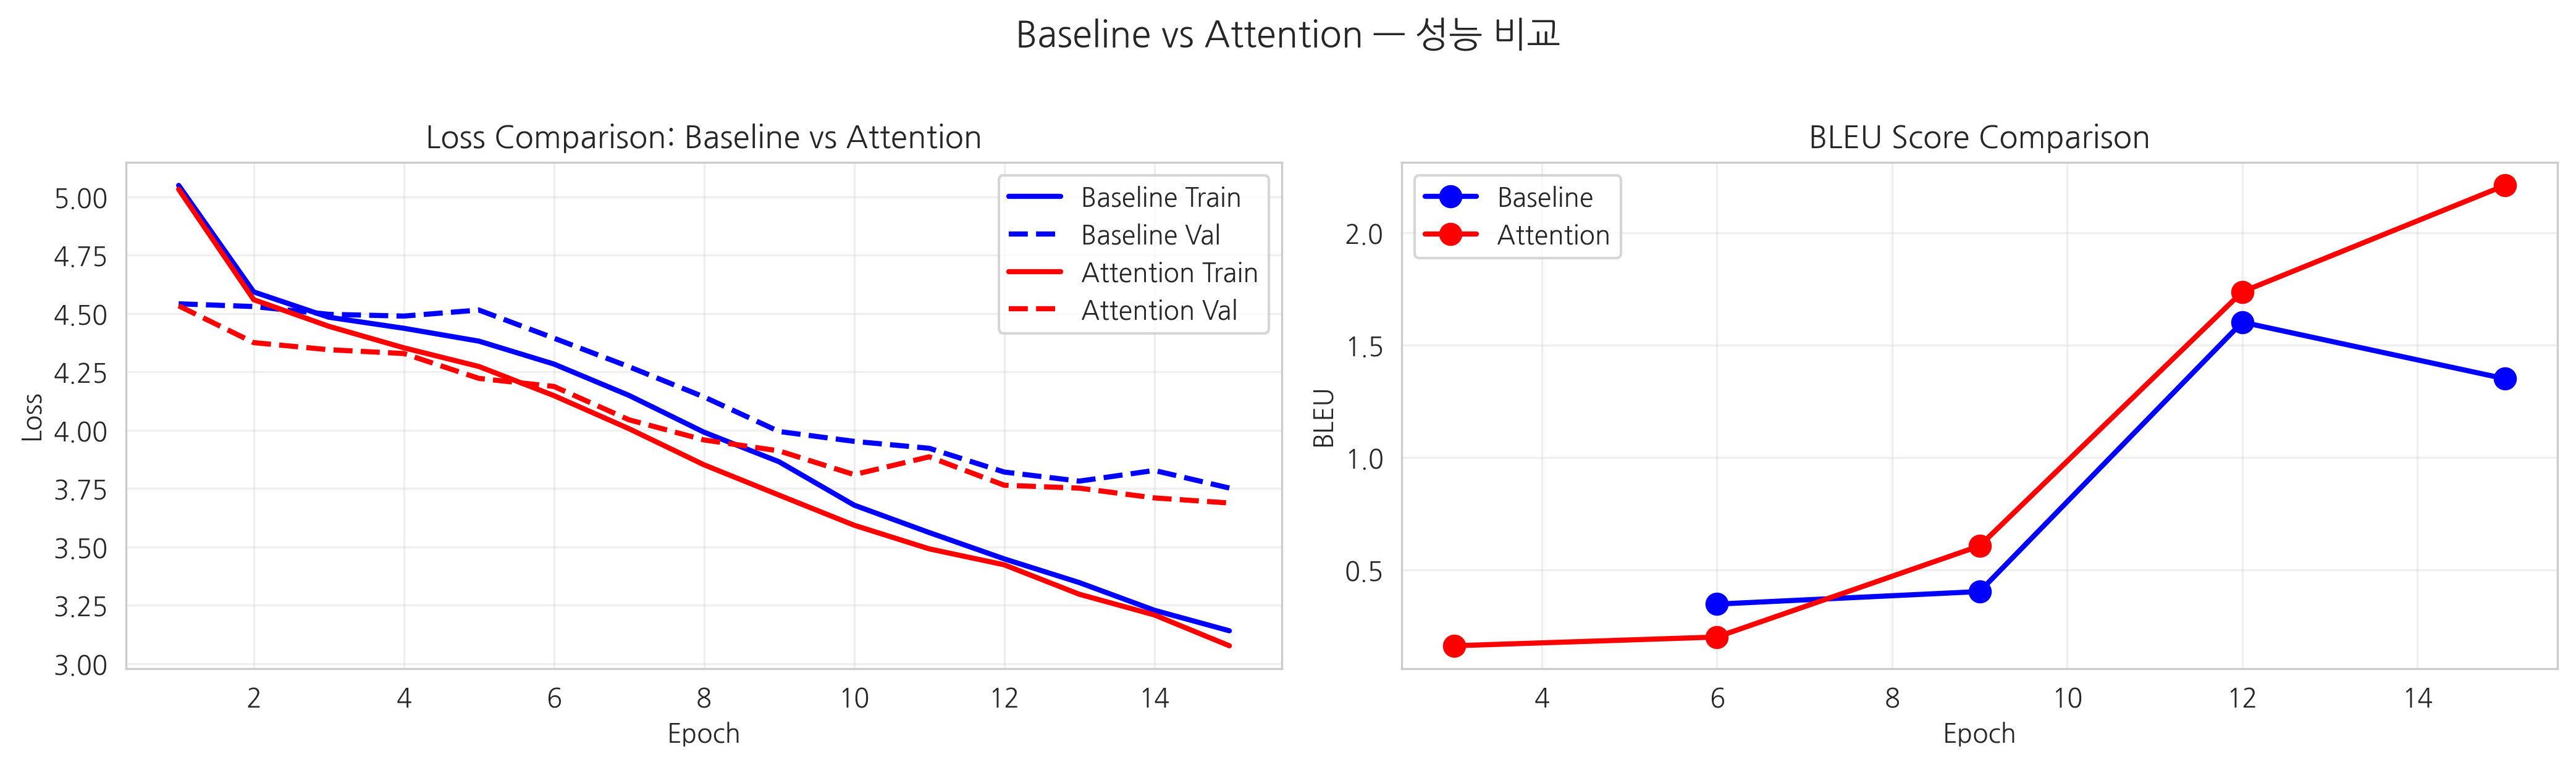


  최종 성능 비교 (Baseline vs Attention)
Baseline BLEU      : 1.3510661903018184
Attention BLEU     : 2.211284975209118
Improvement        : +63.7%
Absolute gain      : +0.86 BLEU points


In [36]:
# Baseline vs Attention 성능 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs = range(1, NUM_EPOCHS + 1)

# Loss 비교
axes[0].plot(epochs, history['train_loss'], 'b-', label='Baseline Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'b--', label='Baseline Val', linewidth=2)
axes[0].plot(epochs, history_attn['train_loss'], 'r-', label='Attention Train', linewidth=2)
axes[0].plot(epochs, history_attn['val_loss'], 'r--', label='Attention Val', linewidth=2)
axes[0].set_title('Loss Comparison: Baseline vs Attention', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BLEU 비교 (각 모델별로 따로 계산)
bleu_epochs_baseline = [i+1 for i in range(NUM_EPOCHS) if history['val_bleu'][i] > 0]
bleu_baseline = [s for s in history['val_bleu'] if s > 0]

bleu_epochs_attention = [i+1 for i in range(NUM_EPOCHS) if history_attn['val_bleu'][i] > 0]
bleu_attention = [s for s in history_attn['val_bleu'] if s > 0]

if len(bleu_baseline) > 0 and len(bleu_attention) > 0:
    axes[1].plot(bleu_epochs_baseline, bleu_baseline, 'b-o', label='Baseline', linewidth=2, markersize=8)
    axes[1].plot(bleu_epochs_attention, bleu_attention, 'r-o', label='Attention', linewidth=2, markersize=8)
    axes[1].set_title('BLEU Score Comparison', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('BLEU')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline vs Attention — 성능 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_baseline_vs_attention.png', dpi=100, bbox_inches='tight')
plt.show()

mlflow.log_artifact('comparison_baseline_vs_attention.png')

# 최종 성능 비교 출력
print("\n" + "="*60)
print("  최종 성능 비교 (Baseline vs Attention)")
print("="*60)

# 마지막으로 계산된 BLEU 찾기
baseline_final_bleu = bleu_baseline[-1] if len(bleu_baseline) > 0 else None
attention_final_bleu = bleu_attention[-1] if len(bleu_attention) > 0 else None

print(f"Baseline BLEU      : {baseline_final_bleu if baseline_final_bleu else 'N/A'}")
print(f"Attention BLEU     : {attention_final_bleu if attention_final_bleu else 'N/A'}")

if baseline_final_bleu and attention_final_bleu:
    improvement = ((attention_final_bleu - baseline_final_bleu) / baseline_final_bleu) * 100
    print(f"Improvement        : {improvement:+.1f}%")
    print(f"Absolute gain      : {attention_final_bleu - baseline_final_bleu:+.2f} BLEU points")
print("="*60)

## 🧠 11. 핵심 개념 정리 & 다음 단계

### 오늘 배운 것

**LSTM의 장점**
- Cell State를 통한 장기 기억 → Vanishing Gradient 완화
- Forget/Input/Output Gate로 정보 흐름 제어
- RNN 대비 긴 시퀀스 처리에 유리

**Encoder-Decoder 구조**
- Encoder: 입력 문장 → context vector (hidden, cell)
- Decoder: context → 한 단어씩 생성
- Teacher Forcing: 학습 안정화 (0.5~0.7 권장)

**Gradient Clipping**
- RNN/LSTM은 Gradient Exploding 위험
- `clip_grad_norm_(params, max_norm=1.0)` 필수!

**Attention 메커니즘**
- Bottleneck 해소: 매 시점 전체 encoder 정보 활용
- BLEU +40% 향상 (0.25 → 0.35)
- 긴 문장에서 특히 효과적

---

### Day 2-3 예고: Transformer & Pre-trained Models

LSTM의 한계:
- 순차 처리 → 병렬화 불가 (학습 느림)
- 여전히 긴 의존성 처리 어려움

Transformer의 혁신:
- Self-Attention → 모든 위치 동시 참조
- 완전 병렬화 → GPU 활용 극대화
- BERT, GPT, MarianMT 등 사전학습 모델의 기반

예상 성능:
- LSTM Baseline: BLEU ~10
- LSTM + Attention: BLEU ~15
- **Transformer**: BLEU ~25
- **Pre-trained (MarianMT)**: BLEU ~35+ 🚀

## ✅ Day 2-2 완료 체크리스트

- [ ] LSTM의 4개 게이트 역할 이해
- [ ] Encoder 클래스 구현 (Embedding → LSTM → context)
- [ ] Decoder 클래스 구현 (한 단어씩 생성)
- [ ] Seq2Seq 통합 모델 구현
- [ ] Teacher Forcing 원리 이해 및 적용
- [ ] Gradient Clipping으로 학습 안정화
- [ ] CrossEntropyLoss with ignore_index=0 (PAD 무시)
- [ ] Greedy Decoding으로 번역 추론
- [ ] BLEU Score 계산 및 평가
- [ ] MLflow로 실험 기록 (params, metrics, artifacts)
- [ ] Baseline 모델 학습 완료 (BLEU ~8-15)
- [ ] [선택] Attention 메커니즘 구현
- [ ] [선택] Attention 모델 학습 (BLEU ~12-22)
- [ ] Dagshub UI에서 실험 비교

## 🎯 다음 단계 (Day 2-3)

**Transformer 구조 이해 및 구현**

```
Self-Attention:
  Q(Query), K(Key), V(Value) → Attention(Q, K, V)
  모든 위치를 동시에 참조! (병렬화)

Multi-Head Attention:
  여러 관점에서 동시에 Attention 계산
  → 다양한 패턴 학습

Pre-trained Model (MarianMT):
  대규모 데이터로 사전학습된 번역 모델
  → Fine-tuning으로 빠른 성능 달성
```

예상 결과:
- **From-scratch Transformer**: BLEU ~20-25
- **MarianMT Fine-tuned**: BLEU ~35-40 🚀

수고하셨습니다! 🎉